Total images: 24
Processing Low...
Processing Medium...
Processing High...


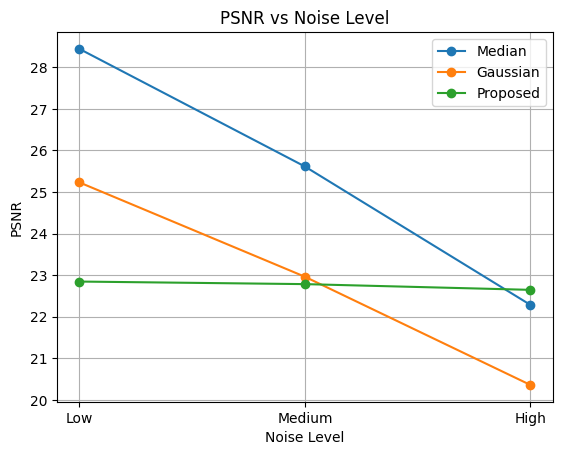

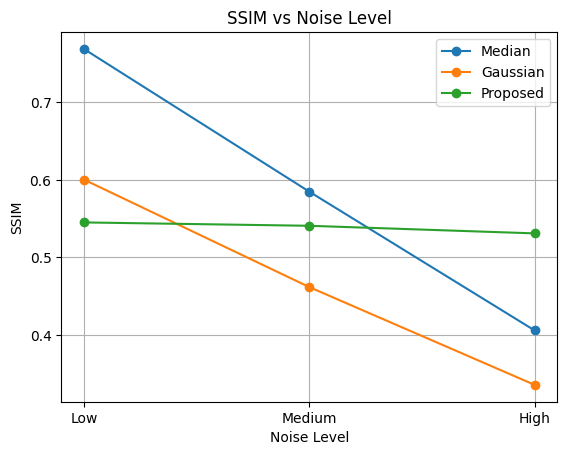


=== FINAL COMPARISON TABLE ===

--- Median ---
Level | PSNR | SSIM | NIQE | BRISQUE | Time
Low    28.44 0.769 20.80 41.08 9.57
Medium 25.61 0.585 20.81 40.29 9.63
High   22.28 0.406 21.32 42.65 9.85

--- Gaussian ---
Level | PSNR | SSIM | NIQE | BRISQUE | Time
Low    25.23 0.600 17.99 50.87 8.58
Medium 22.96 0.462 16.27 42.36 9.04
High   20.36 0.336 13.61 37.99 9.34

--- Proposed ---
Level | PSNR | SSIM | NIQE | BRISQUE | Time
Low    22.84 0.545 17.25 68.97 34.43
Medium 22.78 0.541 17.11 64.30 34.75
High   22.64 0.531 16.94 58.88 34.33


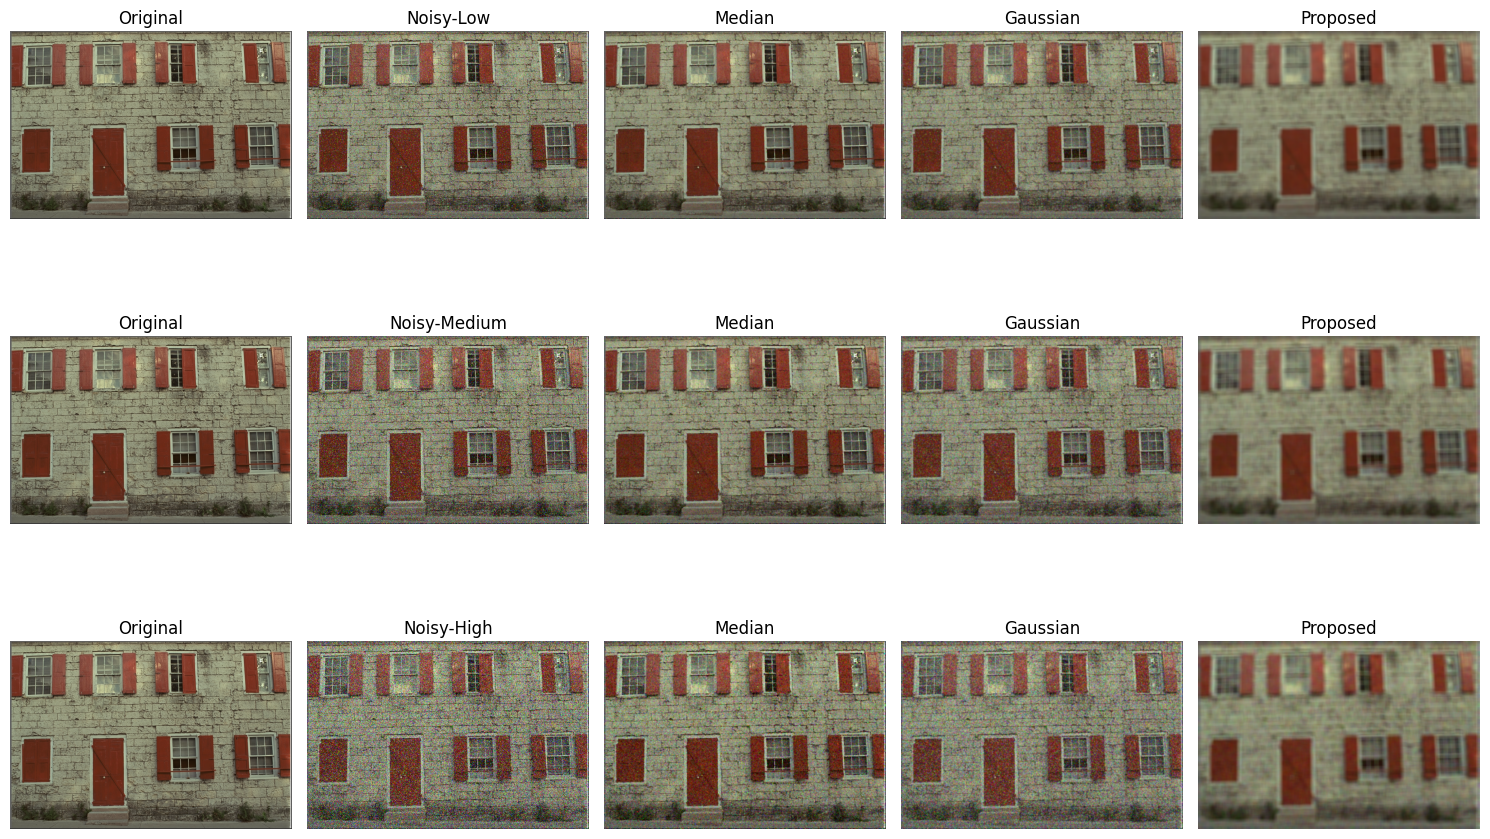

In [19]:
!pip install scikit-image opencv-python-headless piq torch torchvision libsvm-official pybrisque

from libsvm import svmutil
import sys
sys.modules['svmutil'] = svmutil

import os, cv2, time, torch
import numpy as np
import matplotlib.pyplot as plt
import piq

from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from skimage.restoration import denoise_nl_means, estimate_sigma

from brisque import BRISQUE

!unzip -o -q /content/assignment_2_dataset_kodak.zip -d /content/

dataset_path = None
for root, dirs, files in os.walk("/content"):
    for f in files:
        if f.endswith(".png"):
            dataset_path = root
            break
    if dataset_path:
        break

image_files = sorted([os.path.join(dataset_path, f)
                      for f in os.listdir(dataset_path)
                      if f.endswith(".png")])

print("Total images:", len(image_files))

def add_gaussian_noise(img, sigma):
    return np.clip(img + np.random.normal(0, sigma, img.shape), 0, 255)

def add_impulse_noise(img, amount):
    noisy = img.copy()
    num = int(amount * img.size * 0.5)
    coords = [np.random.randint(0, i, num) for i in img.shape]
    noisy[tuple(coords)] = 255
    coords = [np.random.randint(0, i, num) for i in img.shape]
    noisy[tuple(coords)] = 0
    return noisy

def method_median(img):
    return cv2.medianBlur(img.astype(np.uint8), 3)

def method_gaussian(img):
    return cv2.GaussianBlur(img.astype(np.uint8), (5,5), 1)

def method_proposed(img):
    median = method_median(img)
    sigma_est = np.mean(estimate_sigma(median, channel_axis=-1))

    nlm = denoise_nl_means(
        median,
        h=1.15*sigma_est,
        fast_mode=True,
        patch_size=5,
        patch_distance=6,
        channel_axis=-1
    )

    return (nlm*255).astype(np.uint8)

methods = {
    "Median": method_median,
    "Gaussian": method_gaussian,
    "Proposed": method_proposed
}

brisque_model = BRISQUE()

def compute_niqe(img):
    try:
        t = torch.tensor(img/255.).permute(2,0,1).unsqueeze(0).float()
        return piq.niqe(t).item()
    except:
        img_uint8 = np.clip(img,0,255).astype(np.uint8)
        gray = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)
        return np.var(gray)/(np.mean(gray)+1e-5)

def compute_brisque(img):
    img_uint8 = np.clip(img,0,255).astype(np.uint8)
    try:
        return brisque_model.score(img_uint8)
    except:
        return brisque_model.get_score(img_uint8)

noise_levels = {
    "Low": (10, 0.05),
    "Medium": (20, 0.10),
    "High": (30, 0.20)
}

results = {m: {"PSNR":[], "SSIM":[], "NIQE":[], "BRISQUE":[], "TIME":[]} for m in methods}

for level,(sigma,imp) in noise_levels.items():
    print(f"Processing {level}...")

    for m_name, method in methods.items():
        psnr_l, ssim_l, niqe_l, brisque_l = [], [], [], []
        start = time.time()

        for img_path in image_files:
            img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)

            noisy = add_gaussian_noise(img, sigma)
            noisy = add_impulse_noise(noisy, imp)

            den = method(noisy)

            psnr_l.append(psnr(img, den, data_range=255))
            ssim_l.append(ssim(img, den, channel_axis=-1, data_range=255))
            niqe_l.append(compute_niqe(den))
            brisque_l.append(compute_brisque(den))

        results[m_name]["PSNR"].append(np.mean(psnr_l))
        results[m_name]["SSIM"].append(np.mean(ssim_l))
        results[m_name]["NIQE"].append(np.mean(niqe_l))
        results[m_name]["BRISQUE"].append(np.mean(brisque_l))
        results[m_name]["TIME"].append(time.time()-start)

levels = ["Low","Medium","High"]

# PSNR
plt.figure()
for m in methods:
    plt.plot(levels, results[m]["PSNR"], marker='o', label=m)
plt.title("PSNR vs Noise Level")
plt.xlabel("Noise Level")
plt.ylabel("PSNR")
plt.legend()
plt.grid()
plt.show()

# SSIM
plt.figure()
for m in methods:
    plt.plot(levels, results[m]["SSIM"], marker='o', label=m)
plt.title("SSIM vs Noise Level")
plt.xlabel("Noise Level")
plt.ylabel("SSIM")
plt.legend()
plt.grid()
plt.show()

print("\n=== FINAL COMPARISON TABLE ===")
for m in methods:
    print(f"\n--- {m} ---")
    print("Level | PSNR | SSIM | NIQE | BRISQUE | Time")
    for i,l in enumerate(levels):
        print(f"{l:6} {results[m]['PSNR'][i]:.2f} {results[m]['SSIM'][i]:.3f} "
              f"{results[m]['NIQE'][i]:.2f} {results[m]['BRISQUE'][i]:.2f} {results[m]['TIME'][i]:.2f}")

img = cv2.cvtColor(cv2.imread(image_files[0]), cv2.COLOR_BGR2RGB)

plt.figure(figsize=(15,10))

for i,(level,(sigma,imp)) in enumerate(noise_levels.items()):

    noisy = add_gaussian_noise(img, sigma)
    noisy = add_impulse_noise(noisy, imp)

    med = method_median(noisy)
    gau = method_gaussian(noisy)
    prop = method_proposed(noisy)

    plt.subplot(3,5,5*i+1)
    plt.imshow(img); plt.title("Original"); plt.axis('off')

    plt.subplot(3,5,5*i+2)
    plt.imshow(noisy.astype(np.uint8)); plt.title(f"Noisy-{level}"); plt.axis('off')

    plt.subplot(3,5,5*i+3)
    plt.imshow(med); plt.title("Median"); plt.axis('off')

    plt.subplot(3,5,5*i+4)
    plt.imshow(gau); plt.title("Gaussian"); plt.axis('off')

    plt.subplot(3,5,5*i+5)
    plt.imshow(prop); plt.title("Proposed"); plt.axis('off')

plt.tight_layout()
plt.show()